In [ ]:
import pandas as pd

# Load the datasets
qualifiers_df = pd.read_excel('sportsref_download.xls', sheet_name='Worksheet')
all_players_df = pd.read_excel('sportsref_download.xls', sheet_name='Worksheet')

# Inspect the Qualifiers data
print("Qualifiers Info:")
print(qualifiers_df.info())
print("\nQualifiers Head:")
print(qualifiers_df.head())

# Inspect the All Players data
print("\nAll Players Info:")
print(all_players_df.info())
print("\nAll Players Head:")
print(all_players_df.head())

Qualifiers Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   0 non-null      float64
 1   Unnamed: 1   82 non-null     object 
 2   Unnamed: 2   82 non-null     object 
 3   Unnamed: 3   82 non-null     object 
 4   Unnamed: 4   82 non-null     object 
 5   Unnamed: 5   82 non-null     object 
 6   Unnamed: 6   82 non-null     object 
 7   Unnamed: 7   82 non-null     object 
 8   Unnamed: 8   82 non-null     object 
 9   Unnamed: 9   82 non-null     object 
 10  Unnamed: 10  82 non-null     object 
 11  Unnamed: 11  82 non-null     object 
 12  Unnamed: 12  82 non-null     object 
 13  Unnamed: 13  82 non-null     object 
 14  Unnamed: 14  82 non-null     object 
 15  Unnamed: 15  82 non-null     object 
 16  Unnamed: 16  82 non-null     object 
 17  Unnamed: 17  82 non-null     object 
 18  Unnamed: 18  82 non-null     object

In [ ]:
def clean_nwl_data(df):
    # Set the header to the first row and drop the first row
    new_header = df.iloc[0]
    df = df[1:].copy()
    df.columns = new_header

    # Drop the first empty column ('NaN' column)
    df = df.loc[:, df.columns.notnull()]

    # Convert numeric columns to float, except for name/team/position
    cols_to_convert = [col for col in df.columns if col not in ['Player', 'P', 'Team', '#']]
    for col in cols_to_convert:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

qualifiers_clean = clean_nwl_data(qualifiers_df)
all_players_clean = clean_nwl_data(all_players_df)

# Check cleaned data
print("Cleaned Qualifiers Head:")
print(qualifiers_clean.head())
print("\nCleaned Qualifiers Info:")
print(qualifiers_clean.info())

Cleaned Qualifiers Head:
0   #           Player   P Team   G    AVG   AB   R   H  2B  ...    OBP  \
1   9  Piasecki, Aaron  2B  TVC  50  0.406  207  49  84   6  ...  0.492   
2   3  Surowiec, Ethan  OF  DUL  53  0.387  204  48  79  23  ...  0.475   
3  32     Malone, Noah  OF  WAU  55  0.381  202  66  77  15  ...  0.521   
4   3  Algarin, Joshua  OF   BC  61  0.366  235  53  86  11  ...  0.470   
5  22     Allen, Henry  OF  MOT  47  0.366  191  42  70   8  ...  0.456   

0    SLG    OPS   PA    AB/HR  BB/PA   BB/K   SECA   ISOP      RC  
1  0.483  0.975  250  103.500  0.144  4.000  0.333  0.077  49.383  
2  0.779  1.255  244   12.000  0.119  0.707  0.583  0.392  73.700  
3  0.673  1.194  268   14.429  0.179  1.067  0.564  0.292  68.000  
4  0.455  0.925  288  117.500  0.128  0.860  0.289  0.089  48.386  
5  0.649  1.105  226   13.643  0.124  0.651  0.450  0.283  55.489  

[5 rows x 33 columns]

Cleaned Qualifiers Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 1 to 

Correlations with RC and OPS:
0             RC       OPS
0                         
RC      1.000000  0.902396
OPS     0.902396  1.000000
SLG     0.886834  0.963043
H       0.849562  0.643112
RBI     0.753271  0.620288
AVG     0.743454  0.811694
ISOP    0.732849  0.792916
HR      0.705987  0.707903
R       0.705111  0.518408
OBP     0.671920  0.789299
SECA    0.653000  0.641390
2B      0.640520  0.560211
PA      0.498482  0.138037
AB      0.492531  0.107094
3B      0.443178  0.357116
G       0.331012 -0.039345
BB      0.312337  0.124560
SB      0.214053  0.034839
CS      0.188866  0.033399
BB/K    0.180316  0.145313
BB_pct  0.107057  0.078371
BB/PA   0.105852  0.077388
SF      0.086681 -0.019544
HBP     0.043435  0.187577
K       0.041272 -0.104369
PK      0.039806  0.005642
ROE    -0.000541 -0.099020
DP     -0.033428 -0.138091
AB/HR  -0.095636 -0.111507
SH     -0.098024 -0.137454
K_pct  -0.187923 -0.189818

Process Stats Correlation:
0            RC       OPS
0                        

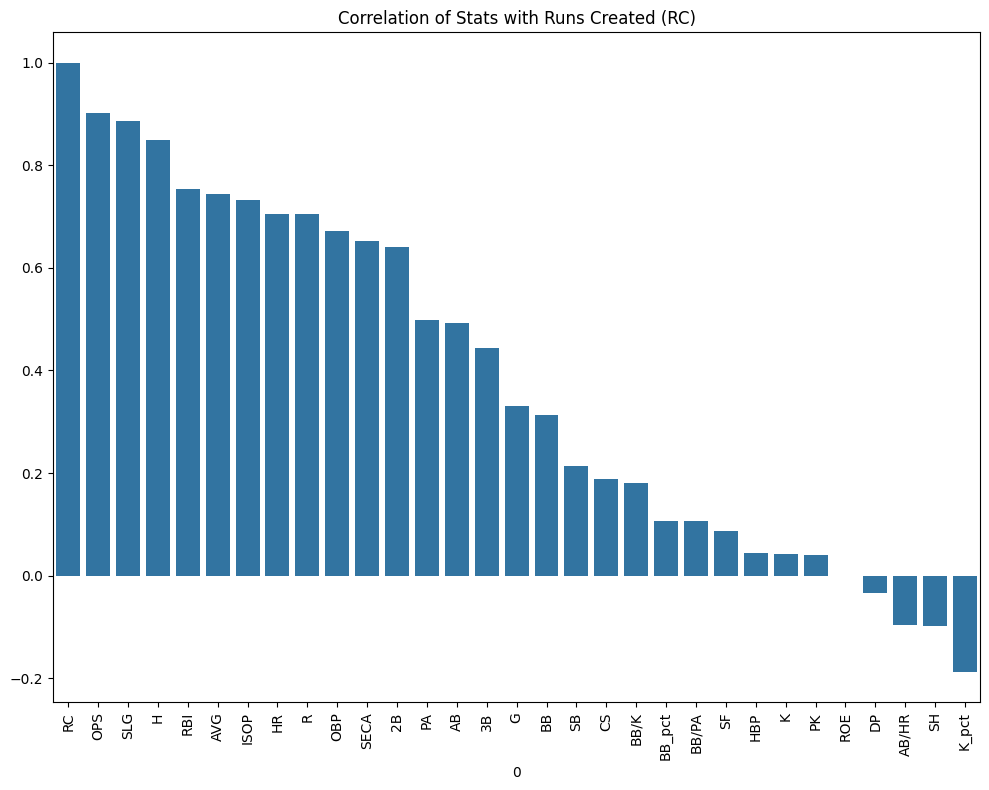

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Engineering
qualifiers_clean['K_pct'] = qualifiers_clean['K'] / qualifiers_clean['PA']
qualifiers_clean['BB_pct'] = qualifiers_clean['BB'] / qualifiers_clean['PA']
# ISO is ISOP in the data.

# Correlation Analysis
correlation_matrix = qualifiers_clean.select_dtypes(include=['float64', 'int64']).corr()

# Focus on correlations with RC (Runs Created) and OPS
target_corrs = correlation_matrix[['RC', 'OPS']].sort_values(by='RC', ascending=False)

print("Correlations with RC and OPS:")
print(target_corrs)

# Plotting the correlations with RC
plt.figure(figsize=(10, 8))
sns.barplot(x=target_corrs['RC'].index, y=target_corrs['RC'].values)
plt.xticks(rotation=90)
plt.title('Correlation of Stats with Runs Created (RC)')
plt.tight_layout()
plt.savefig('correlations_rc.png')

# Identify Top 5 stats (excluding direct counting stats like H, AB, PA, R, etc.)
# We want process stats: BB/PA, K_pct, ISOP, BB/K, AVG, OBP, SLG
process_stats = ['AVG', 'OBP', 'SLG', 'OPS', 'BB/PA', 'BB/K', 'ISOP', 'K_pct', 'SECA']
process_corrs = correlation_matrix.loc[process_stats, ['RC', 'OPS']].sort_values(by='RC', ascending=False)
print("\nProcess Stats Correlation:")
print(process_corrs)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# 1. Filter and Prepare All Players data
# We'll use PA > 50 for a decent sample
df_model = all_players_clean[all_players_clean['PA'] > 50].copy()

# 2. Add Process Metrics
df_model['K_pct'] = df_model['K'] / df_model['PA']
df_model['BB_pct'] = df_model['BB'] / df_model['PA']
# BABIP: (H - HR) / (AB - K - HR + SF)
df_model['BABIP'] = (df_model['H'] - df_model['HR']) / (df_model['AB'] - df_model['K'] - df_model['HR'] + df_model['SF'])
# Handle divisions by zero or NaN
df_model['BABIP'] = df_model['BABIP'].replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. Define Features and Target
# We want to know which 'traits' lead to 'RC'
features = ['AVG', 'BB_pct', 'K_pct', 'ISOP', 'BABIP', 'SB']
target = 'RC'

# Drop rows with NaN in features or target
df_model = df_model.dropna(subset=features + [target])

X = df_model[features]
y = df_model[target]

# 4. Train a Random Forest to find feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("Feature Importance for predicting RC:")
print(feature_importance_df)

# 5. Rank players by a "Scout Score"
# This is a synthetic metric: Higher weight on BB/K and ISOP, lower on BABIP (assuming high BABIP is luck)
# We'll normalize these
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_scale = ['BB_pct', 'ISOP', 'K_pct', 'AVG']
scaled_values = scaler.fit_transform(df_model[cols_to_scale])
df_scaled = pd.DataFrame(scaled_values, columns=cols_to_scale, index=df_model.index)

# Scout Score: 0.4*ISOP + 0.3*BB% - 0.2*K% + 0.1*AVG
df_model['Scout_Score'] = (df_scaled['ISOP'] * 0.4 +
                           df_scaled['BB_pct'] * 0.3 -
                           (1 - df_scaled['K_pct']) * 0.2 +
                           df_scaled['AVG'] * 0.1)

top_prospects = df_model[['Player', 'Team', 'PA', 'AVG', 'ISOP', 'BB_pct', 'K_pct', 'RC', 'Scout_Score']].sort_values(by='Scout_Score', ascending=False)
print("\nTop 15 Prospects (by Scout Score):")
print(top_prospects)

# Save the top prospects to a CSV file for your records or further analysis
top_prospects.to_csv('top_15_prospects.csv', index=False)

Feature Importance for predicting RC:
  Feature  Importance
0     AVG    0.449145
5      SB    0.193233
3    ISOP    0.188438
2   K_pct    0.060062
1  BB_pct    0.056860
4   BABIP    0.052262

Top 15 Prospects (by Scout Score):
0              Player Team   PA    AVG   ISOP    BB_pct     K_pct      RC  \
510    Rogers, Daniel  MAD   51  0.472  0.472  0.274510  0.137255  21.080   
419    Gingrich, Zach  BBS   76  0.273  0.345  0.197368  0.250000  14.571   
252     Cavill, Blake  MOT  144  0.301  0.290  0.298611  0.111111  28.713   
190       Sweeney, MJ  MAD  155  0.316  0.325  0.167742  0.251613  32.329   
288     Felsch, Rowan  MOT  113  0.274  0.333  0.185841  0.194690  21.371   
..                ...  ...  ...    ...    ...       ...       ...     ...   
447    Kuhnke, Camden  FDL   56  0.340  0.020  0.053571  0.089286   6.792   
354     Smith, Sawyer  STC   74  0.304  0.058  0.027027  0.094595   8.099   
251    McNamara, Jake  TVC  106  0.309  0.032  0.066038  0.047170  11.406   
45


Sleeper Targets (High Process, Lower AVG):
0               Player Team   PA    AVG   ISOP      BB_K  Scout_Score
419     Gingrich, Zach  BBS   76  0.273  0.345  0.789474     0.431933
288      Felsch, Rowan  MOT  113  0.274  0.333  0.954545     0.383506
417   Ballinger, Brady  STC   82  0.236  0.164  1.470588     0.360201
263      Taylor, Gavin  RFD  124  0.220  0.187  0.941176     0.359009
310      Mennella, Joe   GB  100  0.231  0.282  0.900000     0.325654
64       Pena, Matthew  WIL  220  0.260  0.254  0.791667     0.310587
489  Knight, Christian  BIS   54  0.225  0.175  0.857143     0.305727
289      Larsen, Brock  WIL  114  0.202  0.167  1.076923     0.302342
382  Viskovich, Bryant  MAN   99  0.172  0.125  0.800000     0.291650
158    Johnson, Trevor  KZO  170  0.223  0.157  1.250000     0.269459


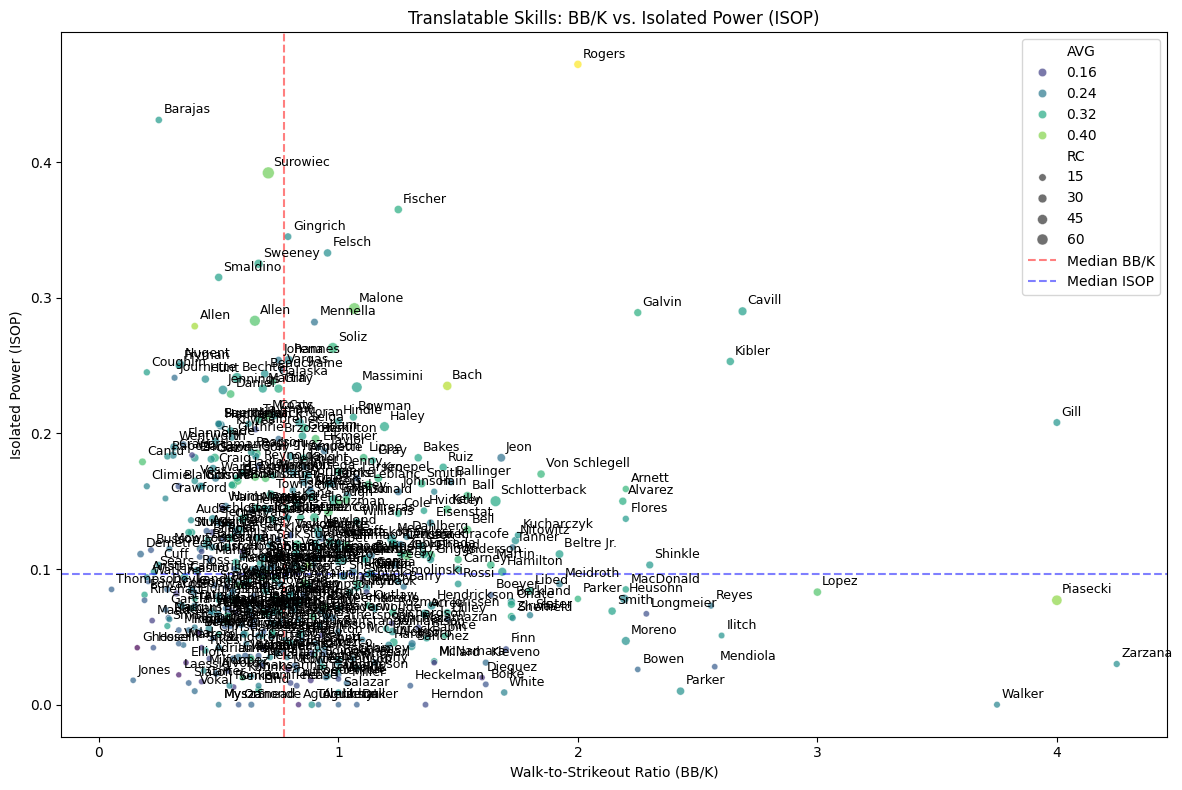

In [ ]:

# Calculate BB/K for the model dataframe
df_model['BB_K'] = df_model['BB'] / df_model['K'].replace(0, 1) # Avoid div by zero

# Scatter plot: BB/K vs ISOP
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_model, x='BB_K', y='ISOP', size='RC', hue='AVG', palette='viridis', alpha=0.7)

# Add thresholds for "Elite" zones (using medians or top quartiles)
plt.axvline(x=df_model['BB_K'].median(), color='red', linestyle='--', alpha=0.5, label='Median BB/K')
plt.axhline(y=df_model['ISOP'].median(), color='blue', linestyle='--', alpha=0.5, label='Median ISOP')

plt.title('Translatable Skills: BB/K vs. Isolated Power (ISOP)')
plt.xlabel('Walk-to-Strikeout Ratio (BB/K)')
plt.ylabel('Isolated Power (ISOP)')
plt.legend()

# Label top prospects
for i in range(top_prospects.shape[0]):
    player_name = top_prospects.iloc[i]['Player']
    player_data = df_model[df_model['Player'] == player_name].iloc[0]
    plt.text(player_data['BB_K'] + 0.02, player_data['ISOP'] + 0.005, player_name.split(',')[0], fontsize=9)

plt.tight_layout()
plt.savefig('translatable_skills_scatter.png')

# Identify "Sleeper" targets: High BB/K and ISOP but lower than .300 AVG
sleepers = df_model[(df_model['BB_K'] > df_model['BB_K'].median()) &
                    (df_model['ISOP'] > df_model['ISOP'].median()) &
                    (df_model['AVG'] < 0.300)].sort_values(by='Scout_Score', ascending=False)

print("\nSleeper Targets (High Process, Lower AVG):")
print(sleepers[['Player', 'Team', 'PA', 'AVG', 'ISOP', 'BB_K', 'Scout_Score']].head(10))

# Export data
df_model.to_csv('2025_NWL_Analyzed_Stats.csv', index=False)

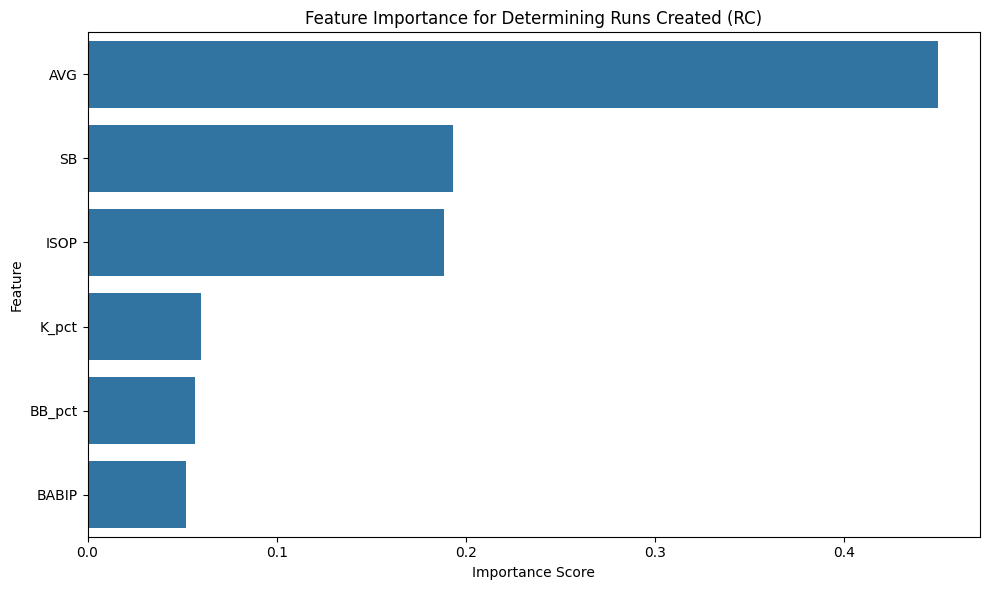

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for Determining Runs Created (RC)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_rc.png')
plt.show()